# Experiment — Feature engineering impact

**Category:** feature_engineering | **Tasks 4, 5, 6**

**Hypothesis:** cyclical calendar encodings, calendar flags, interactions and region one-hot improve accuracy over raw columns alone. We measure RMSE with each group added.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
REPO = Path.cwd()
while not (REPO / "src").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
import numpy as np
import pandas as pd
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from src.data_loading import PROCESSED_DIR, TARGET
from src.features import build_features, split_xy
from src.evaluation import regression_metrics
df = pd.read_csv(PROCESSED_DIR / 'grid_load_clean.csv')
df.head()

,Region,Hour,DayOfWeek,Temperature_C,Humidity_pct,Rainfall_mm,PopulationIndex,IndustrialIndex,SolarGenerationIndex,GridLoad_MW
0,Central,20.0,0.0,26.7,52.0,3.1,93.0,89.0,0.03,850.3
1,Eastern,13.0,0.0,18.5,63.0,3.7,95.0,89.0,0.38,788.3
2,Western,14.0,4.0,22.7,90.0,3.3,71.0,55.0,0.13,548.0
3,Northern,10.0,0.0,19.6,41.0,0.1,75.0,78.0,0.45,604.6
4,Northern,12.0,0.0,27.4,88.0,0.0,86.0,58.0,0.70,546.1


## Task 4/5 — feature sets, from raw to fully engineered

In [2]:
def eval_features(**flags):
    feat = build_features(df, **flags)
    X, y = split_xy(feat)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    m = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    m.fit(Xtr, ytr)
    met = regression_metrics(yte, m.predict(Xte))
    met['n_features'] = X.shape[1]
    return met

configs = {
    'raw only':          dict(cyclical=False, calendar=False, interactions=False, one_hot=True),
    '+ cyclical':        dict(cyclical=True,  calendar=False, interactions=False, one_hot=True),
    '+ calendar flags':  dict(cyclical=True,  calendar=True,  interactions=False, one_hot=True),
    '+ interactions':    dict(cyclical=True,  calendar=True,  interactions=True,  one_hot=True),
}
res = {k: eval_features(**v) for k, v in configs.items()}
board = pd.DataFrame(res).T
board = board[['n_features', 'RMSE', 'MAE', 'R2', 'MAPE']].round(3)
board

,n_features,RMSE,MAE,R2,MAPE
raw only,12.0,22.886,18.360,0.949,3.074
+ cyclical,16.0,23.109,18.517,0.948,3.096
+ calendar flags,19.0,22.785,18.223,0.950,3.043
+ interactions,21.0,18.944,14.810,0.965,2.482


## Task 6 — impact visualization

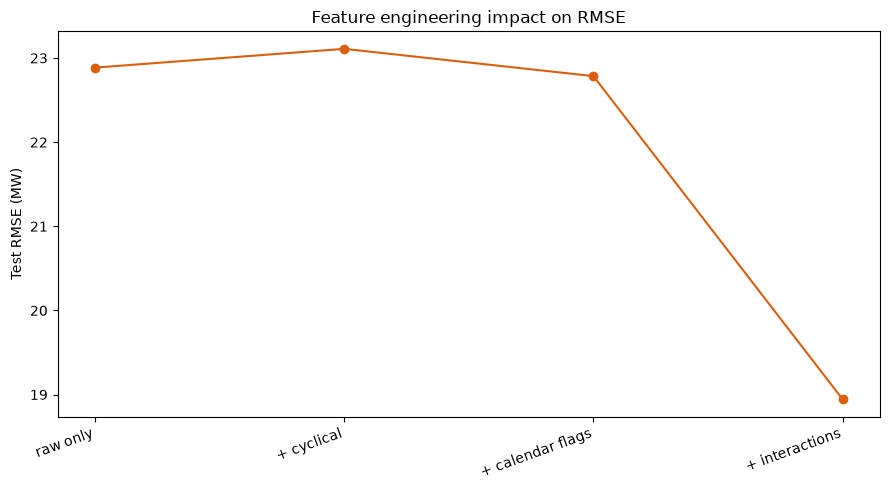

In [3]:
import matplotlib.pyplot as plt
from src.data_loading import FIGURES_DIR
fig, ax = plt.subplots(figsize=(9, 5))
board['RMSE'].plot(marker='o', ax=ax, color='#d95f0e')
ax.set_ylabel('Test RMSE (MW)'); ax.set_title('Feature engineering impact on RMSE')
ax.set_xticks(range(len(board))); ax.set_xticklabels(board.index, rotation=20, ha='right')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'feature_engineering_impact.png', dpi=120)
plt.show()

## Decision
The fully-engineered feature set (cyclical + calendar + interactions + region one-hot) is adopted as the project default in `src/features.py::build_features`. Log the RMSE before→after in `experiment_log.md`.